# Intrusion Detection System — Model Comparison
## Dataset: CSE-CIC-IDS2018 &emsp;|&emsp; Author: Mhd Ghaith al-Atrash
### Networking Engineering &emsp;|&emsp; 4th Year · 2025–2026

---

### Models Compared
| # | Model | Category |
|---|---|---|
| 1 | **CNN-1D** | Deep Learning — Convolutional |
| 2 | **LSTM** | Deep Learning — Recurrent (Long-Short Term) |
| 3 | **Random Forest** | Ensemble ML — Bagging |
| 4 | **LightGBM** | Ensemble ML — Boosting |
| 5 | **XGBoost** | Ensemble ML — Boosting (histogram-based approach) |


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Environment Setup

In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Output directory for saved figures ────────────────────────────────────────
FIGURES = Path('/content/drive/MyDrive/fig_DL')
FIGURES.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIGURES / name, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  ✔  Saved → fig_DL/{name}')

# ── Publication-quality plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#333333',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'figure.titlesize':  15,
})

# ── Consistent color palette (one entry per model in this comparison) ────────
PALETTE = {
    'CNN-1D':        '#E53935',
    'LSTM':          '#8E24AA',
    'Random Forest': '#43A047',
    'LightGBM':      '#FB8C00',
    'XGBoost':       '#1E88E5',
}
BENIGN_CLR = '#43A047'
ATTACK_CLR = '#E53935'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device : {device}')
print(f'Setup complete. Figures will be saved to: {FIGURES.resolve()}')


PyTorch device : cuda
Setup complete. Figures will be saved to: /content/drive/MyDrive/fig_DL


## 2. Load Dataset

The **CSE-CIC-IDS2018** dataset was created by the Canadian Institute for Cybersecurity (CIC) and the Communications Security Establishment (CSE).  
It contains bidirectional network flow records captured over 10 days, spanning benign traffic and 13 distinct attack categories.

Each row represents one network flow described by **80+ statistical features** (packet lengths, inter-arrival times, byte counts, TCP flags, etc.).

> **Loading strategy:** Files are read in chunks to avoid memory exhaustion.  
> A `SAMPLE_PER_FILE` cap controls the total rows loaded for development runs.


In [3]:
DATASET_PATH    = '/content/drive/MyDrive/CSE-CIC-IDS2018'
SAMPLE_PER_FILE = 75_000

def load_real_data(path, sample_per_file):
    all_files = sorted([f for f in os.listdir(path) if f.endswith('.csv')])
    print(f'Found {len(all_files)} CSV file(s)')
    dfs = []
    for fname in all_files:
        print(f'  Loading {fname} ...', end=' ')
        try:
            chunks, total = [], 0
            for chunk in pd.read_csv(os.path.join(path, fname),
                                     chunksize=10_000, low_memory=False):
                chunks.append(chunk)
                total += len(chunk)
                if total >= sample_per_file:
                    break
            fdf = pd.concat(chunks, ignore_index=True).iloc[:sample_per_file]
            print(f'{len(fdf):,} rows | Sample timestamp: {fdf["Timestamp"].head(2).tolist()}')
            dfs.append(fdf)
            print(f'{len(fdf):,} rows | Labels: {fdf["Label"].value_counts().to_dict()}')
        except Exception as exc:
            print(f'ERROR: {exc}')
    return pd.concat(dfs, ignore_index=True)

df = load_real_data(DATASET_PATH, SAMPLE_PER_FILE)
print(f'\n{"-"*50}')
print(f'Total shape   : {df.shape}')
print(f'Columns       : {df.shape[1]}')
print(f'\nLabel distribution:\n{df["Label"].value_counts()}')


Found 10 CSV file(s)
  Loading 02-14-2018.csv ... 75,000 rows | Sample timestamp: ['14/02/2018 08:31:01', '14/02/2018 08:33:50']
75,000 rows | Labels: {'FTP-BruteForce': 74890, 'Benign': 110}
  Loading 02-15-2018.csv ... 75,000 rows | Sample timestamp: ['15/02/2018 08:25:18', '15/02/2018 08:29:05']
75,000 rows | Labels: {'DoS attacks-GoldenEye': 41508, 'Benign': 22502, 'DoS attacks-Slowloris': 10990}
  Loading 02-16-2018.csv ... 75,000 rows | Sample timestamp: ['16/02/2018 08:27:23', '16/02/2018 08:30:12']
75,000 rows | Labels: {'DoS attacks-SlowHTTPTest': 74872, 'Benign': 128}
  Loading 02-20-2018.csv ... 75,000 rows | Sample timestamp: ['20/02/2018 08:34:07', '20/02/2018 08:33:22']
75,000 rows | Labels: {'DDoS attacks-LOIC-HTTP': 74921, 'Benign': 79}
  Loading 02-21-2018.csv ... 75,000 rows | Sample timestamp: ['21/02/2018 08:33:25', '21/02/2018 08:33:06']
75,000 rows | Labels: {'DDOS attack-HOIC': 71067, 'Benign': 2203, 'DDOS attack-LOIC-UDP': 1730}
  Loading 02-22-2018.csv ... 75,0

## 3. Preprocessing

### Key anti-leakage rules enforced here
- Rows sorted **chronologically** before any split — prevents accidental future-data leakage
- Exact duplicates removed from the full dataset (safe — no label information is used)
- All imputation values, feature selectors, and scalers are **fit on the training fold only**
- Binary label created: `Benign → 0`, everything else `→ 1`


In [4]:
# ── Remove exact duplicates ────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed : {before - len(df):,}  →  {len(df):,} rows remain')

# ── Remove phantom header rows ─────────────────────────────────────────────────
df = df[df['Label'] != 'Label'].reset_index(drop=True)
df = df[df['Timestamp'] != 'Timestamp'].reset_index(drop=True)

# ── Parse & sort by timestamp ─────────────────────────────────────────────────
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
invalid_ts = df['Timestamp'].isna().sum()
if invalid_ts:
    print(f'Dropping {invalid_ts:,} rows with unparseable Timestamp')
    df = df.dropna(subset=['Timestamp']).reset_index(drop=True)
df = df.sort_values('Timestamp').reset_index(drop=True)
print(f'Date range        : {df["Timestamp"].min()}  →  {df["Timestamp"].max()}')

# ── Binary label ──────────────────────────────────────────────────────────────
df['Binary_Label'] = (df['Label'] != 'Benign').astype(int)
y = df['Binary_Label'].copy()
print(f'\nBenign  : {(y==0).sum():>8,}  ({(y==0).mean():.2%})')
print(f'Attack  : {(y==1).sum():>8,}  ({(y==1).mean():.2%})')
print(f'Imbalance ratio (neg/pos) : {(y==0).sum()/(y==1).sum():.2f}')


Duplicates removed : 120,479  →  629,521 rows remain
Date range        : 2018-02-14 08:30:38  →  2018-03-02 12:59:59

Benign  :  339,651  (53.95%)
Attack  :  289,869  (46.05%)
Imbalance ratio (neg/pos) : 1.17


## 4. Exploratory Data Analysis (EDA)


  ✔  Saved → fig_DL/01_target_distribution.png


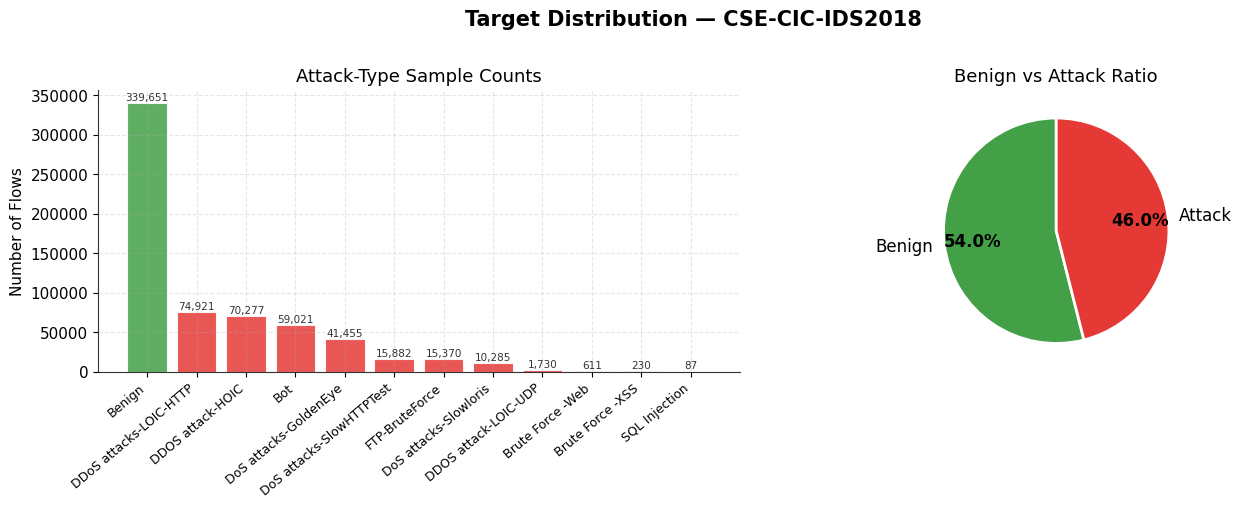

In [5]:
# ── Figure 1: Target Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Distribution — CSE-CIC-IDS2018', fontsize=15, fontweight='bold', y=1.01)

counts     = df['Label'].value_counts()
bar_colors = [BENIGN_CLR if l == 'Benign' else ATTACK_CLR for l in counts.index]

axes[0].bar(range(len(counts)), counts.values, color=bar_colors,
            alpha=0.85, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=40, ha='right', fontsize=9)
axes[0].set_title('Attack-Type Sample Counts')
axes[0].set_ylabel('Number of Flows')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts)*0.01, f'{v:,}', ha='center', fontsize=7.5, color='#333')

bc     = df['Binary_Label'].value_counts().sort_index()
wedges, texts, autotexts = axes[1].pie(
    bc, labels=['Benign', 'Attack'],
    autopct='%1.1f%%',
    colors=[BENIGN_CLR, ATTACK_CLR],
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Benign vs Attack Ratio')

plt.tight_layout()
savefig('01_target_distribution.png')
plt.show()


  ✔  Saved → fig_DL/02_traffic_timeline.png


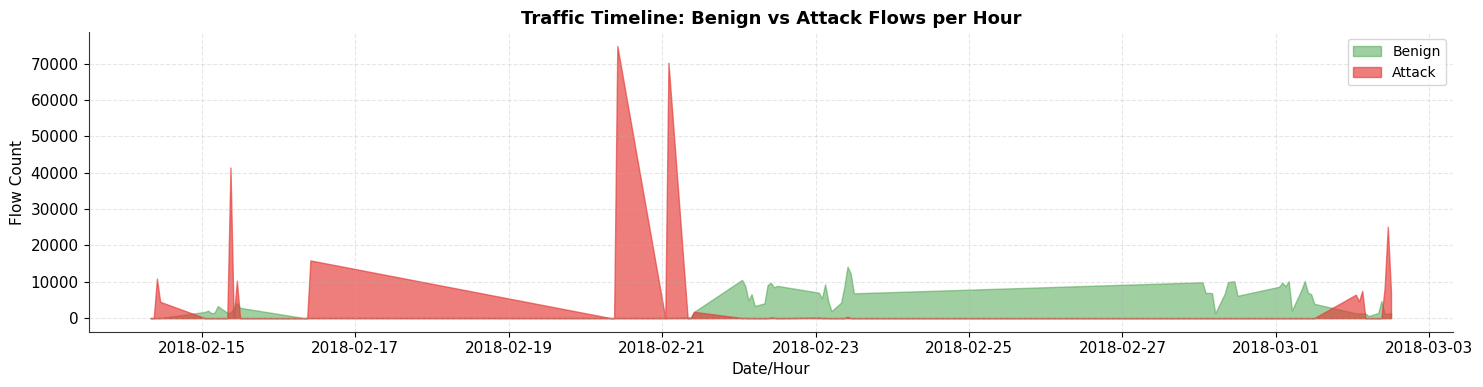

In [6]:
# ── Figure 2: Traffic Timeline ────────────────────────────────────────────────
df['Hour'] = df['Timestamp'].dt.floor('h')
hourly = df.groupby(['Hour', 'Binary_Label']).size().unstack(fill_value=0)
hourly.columns = ['Benign', 'Attack']

fig, ax = plt.subplots(figsize=(15, 4))
ax.fill_between(hourly.index, hourly['Benign'], alpha=0.50, color=BENIGN_CLR, label='Benign')
ax.fill_between(hourly.index, hourly['Attack'], alpha=0.65, color=ATTACK_CLR, label='Attack')
ax.set_title('Traffic Timeline: Benign vs Attack Flows per Hour', fontweight='bold')
ax.set_xlabel('Date/Hour')
ax.set_ylabel('Flow Count')
ax.legend(loc='upper right')
plt.tight_layout()
savefig('02_traffic_timeline.png')
plt.show()


In [7]:
# ── Prepare feature matrix (needed for EDA figs 3–5) ─────────────────────────
skip_cols = {'Label', 'Binary_Label', 'Timestamp', 'Hour', 'Date'}
feat_cols  = [c for c in df.columns if c not in skip_cols]
X_raw      = df[feat_cols].copy().apply(pd.to_numeric, errors='coerce')
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Raw feature matrix : {X_raw.shape}')
print(f'NaN values         : {X_raw.isna().sum().sum():,}')


Raw feature matrix : (629520, 82)
NaN values         : 2,448,880


  ✔  Saved → fig_DL/03_feature_correlation.png


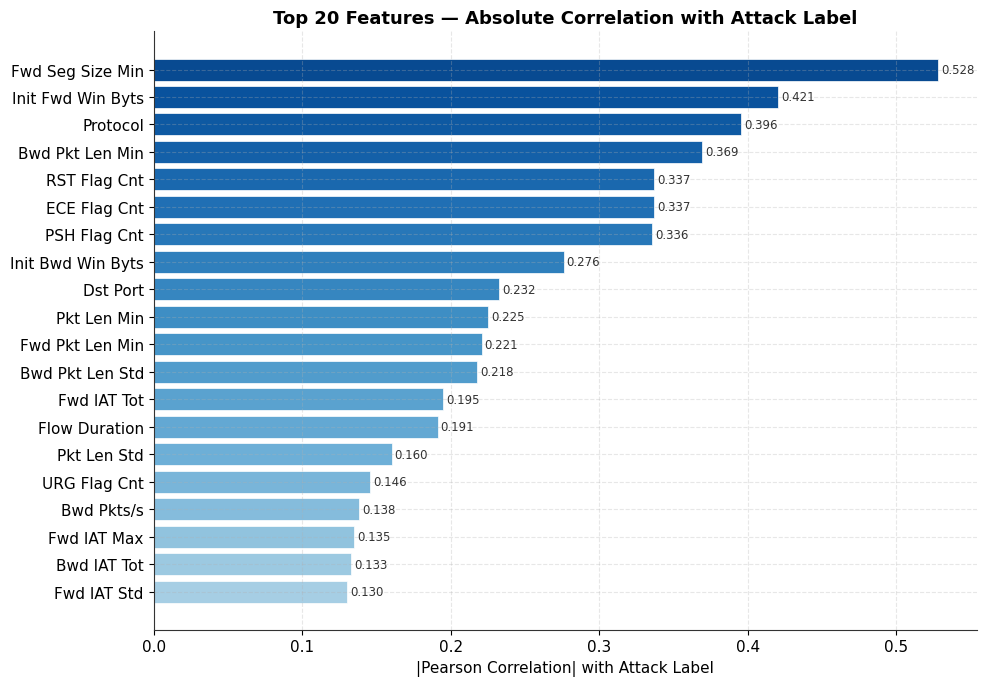

Top feature: Fwd Seg Size Min  (|r| = 0.528)


In [8]:
# ── Figure 3: Feature Correlation with Attack Label ──────────────────────────
# Compute on full dataset (EDA only — no leakage risk before split)
corr_eda = (X_raw.fillna(X_raw.median())
               .corrwith(y)
               .abs()
               .sort_values(ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.35, 0.90, 20))[::-1]
bars = ax.barh(corr_eda.index[::-1], corr_eda.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('|Pearson Correlation| with Attack Label')
ax.set_title('Top 20 Features — Absolute Correlation with Attack Label',
             fontweight='bold')
for bar, val in zip(bars, corr_eda.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5, color='#333')
plt.tight_layout()
savefig('03_feature_correlation.png')
plt.show()
print(f'Top feature: {corr_eda.index[0]}  (|r| = {corr_eda.iloc[0]:.3f})')


  ✔  Saved → fig_DL/04_feature_distributions.png


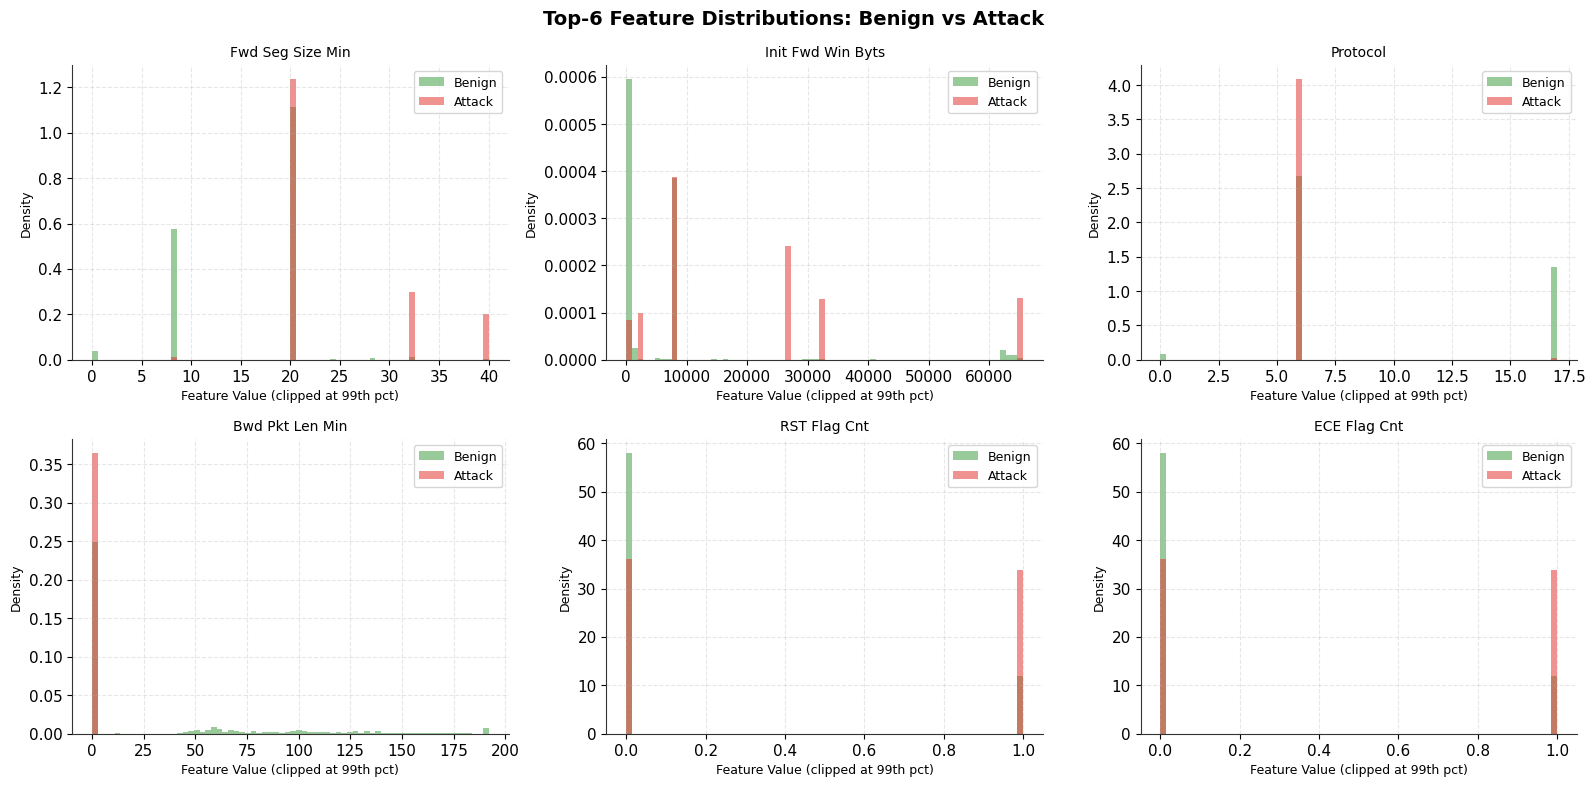

In [9]:
# ── Figure 4: Top-6 Feature Distributions ────────────────────────────────────
top6 = corr_eda.head(6).index.tolist()
Xfill = X_raw.fillna(X_raw.median())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(top6):
    q99 = Xfill[feat].quantile(0.99)
    b   = Xfill.loc[y == 0, feat].clip(upper=q99)
    a   = Xfill.loc[y == 1, feat].clip(upper=q99)
    axes[i].hist(b, bins=70, alpha=0.55, color=BENIGN_CLR,
                 label='Benign', density=True)
    axes[i].hist(a, bins=70, alpha=0.55, color=ATTACK_CLR,
                 label='Attack', density=True)
    axes[i].set_title(feat[:40], fontsize=10)
    axes[i].set_xlabel('Feature Value (clipped at 99th pct)', fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=9)

fig.suptitle('Top-6 Feature Distributions: Benign vs Attack',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('04_feature_distributions.png')
plt.show()


## 5. Time-Based Train / Validation / Test Split

A **60 / 20 / 20 stratified time-based split** is applied:

- **Train (60%)** — used to fit all transformers and model parameters
- **Validation (20%)** — used *only* for threshold tuning and early stopping; no model parameters are updated using test-set information
- **Test (20%)** — held out until final evaluation; never touched at any point during training

Stratification ensures the attack/benign ratio is preserved across splits while maintaining chronological order.


In [10]:
print("Parsing timestamps for proper temporal structuring...")
df['Parsed_Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
if df['Parsed_Timestamp'].isna().sum() > 0:
    df = df.dropna(subset=['Parsed_Timestamp'])

# Extract the specific calendar date to group activities
df['Date_Group'] = df['Parsed_Timestamp'].dt.date

train_list, val_list, test_list = [], [], []

# Chronologically split *each day* individually to balance the attack distributions
for date, group in df.groupby('Date_Group'):
    # Sort this specific day chronologically
    group_sorted = group.sort_values(by='Parsed_Timestamp').reset_index(drop=True)

    n = len(group_sorted)
    if n < 3:
        continue

    idx1 = int(n * 0.60)
    idx2 = int(n * 0.80)

    train_list.append(group_sorted.iloc[:idx1])
    val_list.append(group_sorted.iloc[idx1:idx2])
    test_list.append(group_sorted.iloc[idx2:])

# Combine the temporal blocks back together
df_train = pd.concat(train_list, ignore_index=True)
df_val   = pd.concat(val_list, ignore_index=True)
df_test  = pd.concat(test_list, ignore_index=True)

# Clean up tracking columns
for target_df in [df_train, df_val, df_test]:
    target_df.drop(columns=['Parsed_Timestamp', 'Date_Group'], errors='ignore', inplace=True)

print(f"Stratified Chronological Split Completed:")
print(f"  ↳ Train Set : {df_train.shape[0]} rows ({df_train['Binary_Label'].sum()} malicious | {df_train['Binary_Label'].mean()*100:.1f}% attack ratio)")
print(f"  ↳ Val Set   : {df_val.shape[0]} rows ({df_val['Binary_Label'].sum()} malicious | {df_val['Binary_Label'].mean()*100:.1f}% attack ratio)")
print(f"  ↳ Test Set  : {df_test.shape[0]} rows ({df_test['Binary_Label'].sum()} malicious | {df_test['Binary_Label'].mean()*100:.1f}% attack ratio)")

Parsing timestamps for proper temporal structuring...
Stratified Chronological Split Completed:
  ↳ Train Set : 377709 rows (171840 malicious | 45.5% attack ratio)
  ↳ Val Set   : 125904 rows (62489 malicious | 49.6% attack ratio)
  ↳ Test Set  : 125907 rows (55540 malicious | 44.1% attack ratio)


## 6. Feature Engineering & Preprocessing Pipeline

All steps below are **fit on the training fold only** and applied identically to val and test:

1. **Median imputation** — replaces NaN/Inf using train-set medians
2. **Variance thresholding** — drops near-constant features (threshold = 0.01)
3. **Correlation pruning** — drops one feature from each pair with |r| > 0.95
4. **StandardScaler** — zero-mean, unit-variance normalization


In [11]:
print("Starting Preprocessing Pipeline...")

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Force numeric conversion & handle infinities across all splits
# ─────────────────────────────────────────────────────────────────────────────
for f in feat_cols:
    # Coerce text numbers/corrupted entries into real floats.
    # Any completely non-numeric characters turn into NaN safely.
    df_train[f] = pd.to_numeric(df_train[f], errors='coerce')
    df_val[f]   = pd.to_numeric(df_val[f], errors='coerce')
    df_test[f]  = pd.to_numeric(df_test[f], errors='coerce')

    # Replace true numerical infinities with NaN
    df_train[f] = df_train[f].replace([np.inf, -np.inf], np.nan)
    df_val[f]   = df_val[f].replace([np.inf, -np.inf], np.nan)
    df_test[f]  = df_test[f].replace([np.inf, -np.inf], np.nan)

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Extract train medians and apply manual imputation
# ─────────────────────────────────────────────────────────────────────────────
# Compute medians strictly on the training set to prevent leakage
train_medians = df_train[feat_cols].median()

# Fallback boundary: If an entire column was NaN/Inf in train, fill its median with 0.0
train_medians = train_medians.fillna(0.0)

# Fill missing values across all sets using the fixed training medians
X_train_raw = df_train[feat_cols].fillna(train_medians).values
X_val_raw   = df_val[feat_cols].fillna(train_medians).values
X_test_raw  = df_test[feat_cols].fillna(train_medians).values

y_train = df_train['Binary_Label'].values
y_val   = df_val['Binary_Label'].values
y_test  = df_test['Binary_Label'].values

print(f"Step 1 — Imputation complete. Remaining NaN in train: {np.isnan(X_train_raw).sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 3: Variance Thresholding
# ─────────────────────────────────────────────────────────────────────────────
# Removes columns where values barely change (low variance)
var_sel = VarianceThreshold(threshold=0.01)
X_train_v = var_sel.fit_transform(X_train_raw)
X_val_v   = var_sel.transform(X_val_raw)
X_test_v  = var_sel.transform(X_test_raw)

kept_indices_v = np.where(var_sel.get_support())[0]
feat_cols_v = [feat_cols[i] for i in kept_indices_v]
print(f"Step 2 — Variance filter complete. Kept {X_train_v.shape[1]} features.")

# ─────────────────────────────────────────────────────────────────────────────
# Step 4: Correlation Pruning
# ─────────────────────────────────────────────────────────────────────────────
# Drops highly redundant features with collinearity > 0.95
df_corr_check = pd.DataFrame(X_train_v, columns=feat_cols_v)
corr_matrix = df_corr_check.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

feat_cols_final = [c for c in feat_cols_v if c not in to_drop]
final_indices = [feat_cols_v.index(c) for c in feat_cols_final]

X_train_c = X_train_v[:, final_indices]
X_val_c   = X_val_v[:, final_indices]
X_test_c  = X_test_v[:, final_indices]
print(f"Step 3 — Correlation prune complete. Dropped {len(to_drop)} features. Remaining: {X_train_c.shape[1]}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 5: Standard Scaling
# ─────────────────────────────────────────────────────────────────────────────
# Normalizes features to standard normal distribution (mean=0, variance=1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_c)
X_val   = scaler.transform(X_val_c)
X_test  = scaler.transform(X_test_c)

print("Step 4 — Standard Scaling complete.")
print(f"Final Data Shapes:\n  Train X: {X_train.shape}\n  Val X:   {X_val.shape}\n  Test X:  {X_test.shape}")

# Update global feature count variable for neural network architecture layers
n_feat = X_train.shape[1]

Starting Preprocessing Pipeline...
Step 1 — Imputation complete. Remaining NaN in train: 0
Step 2 — Variance filter complete. Kept 68 features.
Step 3 — Correlation prune complete. Dropped 22 features. Remaining: 46
Step 4 — Standard Scaling complete.
Final Data Shapes:
  Train X: (377709, 46)
  Val X:   (125904, 46)
  Test X:  (125907, 46)


  ✔  Saved → fig_DL/05_split_distribution.png


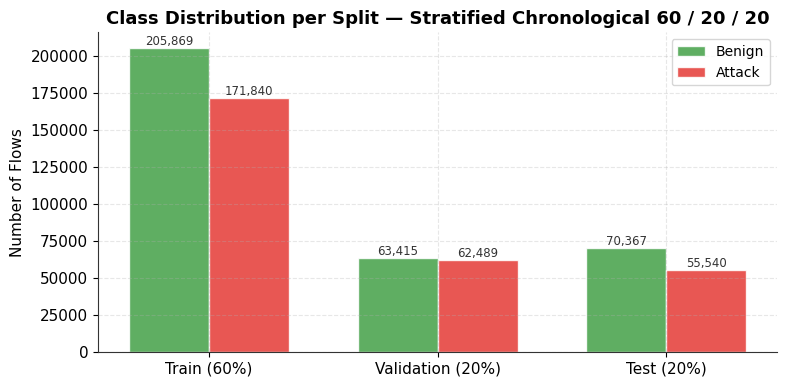

In [12]:
# ── Figure 5: Split Class Distribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x  = np.arange(3)
w  = 0.35

# Fix: Using y_train, y_val, and y_test instead of y_tr, y_va, y_te
ax.bar(x - w/2, [(y_train==0).sum(), (y_val==0).sum(), (y_test==0).sum()],
       w, label='Benign', color=BENIGN_CLR, alpha=0.85, edgecolor='white')
ax.bar(x + w/2, [(y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()],
       w, label='Attack', color=ATTACK_CLR, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
# Adjusted labels to accurately show your 60/20/20 chronological split
ax.set_xticklabels(['Train (60%)', 'Validation (20%)', 'Test (20%)'], fontsize=11)
ax.set_ylabel('Number of Flows')
ax.set_title('Class Distribution per Split — Stratified Chronological 60 / 20 / 20', fontweight='bold')
ax.legend()

# Find the maximum bar height to compute a clean padding for text labels
all_heights = [p.get_height() for p in ax.patches]
max_height = max(all_heights) if all_heights else 100000

for bar in ax.patches:
    height = bar.get_height()
    # Skip drawing a label if the height is zero to prevent overlap clutter
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                height + max_height * 0.01, # Fix: Clean dynamic padding without y.value_counts
                f'{int(height):,}',
                ha='center', fontsize=8.5, color='#333')

plt.tight_layout()
savefig('05_split_distribution.png')
plt.show()

## 7. Shared Utilities

### Functions
- `find_best_threshold` — F1-optimal probability cut-off on the validation set
- `evaluate_model` — computes all metrics, prints classification report, saves confusion matrix
- `make_loader` — wraps NumPy arrays into PyTorch `DataLoader` objects
- `train_dl_model` — generic DL training loop with early stopping, gradient clipping, LR scheduling
- `predict_proba_dl` — batch inference returning sigmoid probabilities


In [13]:
results = {}   # centralized results store — populated by evaluate_model()

# ─────────────────────────────────────────────────────────────────────────────
def find_best_threshold(y_true, y_proba):
    """Return the F1-optimal probability threshold tuned on the validation set."""
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    # Drop last prec/rec pair — it has no corresponding threshold
    prec, rec = prec[:-1], rec[:-1]
    f1s       = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx  = np.argmax(f1s)
    thr       = float(thresholds[best_idx])
    # Safety clip to avoid degenerate thresholds
    return float(np.clip(thr, 0.05, 0.95))

# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_proba, train_time, infer_time):
    """Compute all metrics, print summary, save confusion matrix figure."""
    acc      = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, zero_division=0)
    rec      = recall_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc  = auc(fpr, tpr)

    results[name] = {
        'Accuracy':       round(acc  * 100, 2),
        'Precision':      round(prec * 100, 2),
        'Recall':         round(rec  * 100, 2),
        'F1-Score':       round(f1   * 100, 2),
        'ROC-AUC':        round(roc_auc * 100, 2),
        'Train Time (s)': round(train_time, 2),
        'Infer Time (s)': round(infer_time, 4),
        'fpr': fpr, 'tpr': tpr,
        'color': PALETTE.get(name, '#607D8B'),
        'pred': y_pred, 'proba': y_proba,
    }

    header = f' {name} '
    print(f'\n{"═"*54}')
    print(f'{header:^54}')
    print(f'{"═"*54}')
    print(f'  Accuracy  : {acc*100:6.2f}%')
    print(f'  Precision : {prec*100:6.2f}%')
    print(f'  Recall    : {rec*100:6.2f}%')
    print(f'  F1-Score  : {f1*100:6.2f}%')
    print(f'  ROC-AUC   : {roc_auc*100:6.2f}%')
    print(f'  Train Time: {train_time:.2f}s  |  Infer Time: {infer_time:.4f}s')
    print(f'{"─"*54}')
    print(classification_report(y_true, y_pred,
                                target_names=['Benign', 'Attack'],
                                digits=4))

    cm  = confusion_matrix(y_true, y_pred)
    clr = PALETTE.get(name, '#607D8B')
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=sns.light_palette(clr, as_cmap=True),
                ax=ax,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    savefig(f'cm_{name.replace(" ","_").replace("-","")}.png')
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
def make_loader(X, y, is_sequential=False, batch_size=2048, shuffle=True):
    """Wrap numpy arrays into a PyTorch DataLoader.
    Expands sequence dimensions only if the model requires it (RNN, LSTM, GRU, CNN-1D).
    """
    if is_sequential and X.ndim == 2:
        Xt = torch.FloatTensor(X).unsqueeze(1)   # Shape: (N, 1, F)
    else:
        Xt = torch.FloatTensor(X)                # Shape: (N, F) for standard DNNs

    yt = torch.FloatTensor(y)
    return DataLoader(TensorDataset(Xt, yt),
                      batch_size=batch_size,
                      shuffle=shuffle,
                      pin_memory=(device.type == 'cuda'))

# ─────────────────────────────────────────────────────────────────────────────
def train_dl_model(model, name, train_loader, val_loader, epochs=25, lr=0.001, patience=5):
    print(f'\nTraining {name} ...')
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    history = {'loss': [], 'val_f1': []}
    best_f1 = -1.0
    best_state = None
    patience_cnt = 0

    for epoch in range(epochs):
        # ─── TRAINING PHASE ───
        model.train()
        total_train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # ─── VALIDATION PHASE (Fixed to utilize val_loader properly) ───
        model.eval()
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                probs = torch.sigmoid(logits)

                val_preds.extend(probs.cpu().numpy())
                val_targets.extend(yb.numpy())

        # Calculate real epoch metrics
        avg_train_loss = total_train_loss / len(train_loader)
        val_preds = np.array(val_preds)
        val_targets = np.array(val_targets)

        # Calculate F1 score safely on a fixed threshold
        vf1 = f1_score(val_targets, (val_preds >= 0.5).astype(int), zero_division=0)

        history['loss'].append(avg_train_loss)
        history['val_f1'].append(vf1)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:2d}/{epochs} | train_loss={avg_train_loss:.4f} | val_f1={vf1:.4f}')

        # Early Stopping Check
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'  ⏹ Early stopping at epoch {epoch+1} (Best Val F1 = {best_f1:.4f})')
                break

    if best_state:
        model.load_state_dict(best_state)

    print(f'  ✔ {name} training complete.')
    return model, history

# ─────────────────────────────────────────────────────────────────────────────
def predict_proba_dl(model, X):
    """Batch inference returning flat sigmoid probabilities safely.
    Checks model structural types dynamically to expand or preserve dimensions.
    """
    model.eval()
    vp = []

    # Check if the model uses Recurrent Layers (RNN/LSTM/GRU) or 1D-CNN
    model_name = model.__class__.__name__.lower()
    is_sequential_model = any(x in model_name for x in ['rnn', 'lstm', 'gru', 'cnn', 'conv'])

    if is_sequential_model and X.ndim == 2:
        X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    else:
        X_tensor = torch.tensor(X, dtype=torch.float32)

    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=1024, shuffle=False)

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            vp.append(probs.cpu().numpy())

    return np.concatenate(vp)

# ─────────────────────────────────────────────────────────────────────────────
def plot_training_curves(hist, name):
    """Plot and save training loss + validation F1 curves cleanly.
    Ensures X-axis matches the exact number of actual tracked epochs.
    """
    # 1. Dynamically compute the exact sequential list of epochs run
    num_epochs = len(hist['loss'])
    epochs_range = list(range(1, num_epochs + 1))

    # 2. Check if we actually have data points to plot
    if num_epochs == 0:
        print(f"Warning: History for {name} is empty. Cannot draw training curves.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    clr = PALETTE.get(name, '#607D8B')

    # ── Left Plot: Training Loss (BCE) ───────────────────────────────────────
    axes[0].plot(epochs_range, hist['loss'], color=clr, linewidth=2.2, marker='o', markersize=5, label='Train Loss')
    axes[0].set_title(f'{name} — Training Loss (BCE)', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_xticks(epochs_range)  # Force integer ticks for every epoch
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # ── Right Plot: Validation F1-Score ──────────────────────────────────────
    axes[1].plot(epochs_range, hist['val_f1'], color='#FF9800', linewidth=2.2, marker='s', markersize=5, label='Val F1')
    axes[1].set_title(f'{name} — Validation F1-Score (th=0.5)', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_ylim(-0.05, 1.05)     # Enforce a stable 0-1 vertical bounding view
    axes[1].set_xticks(epochs_range)  # Force matching integer ticks
    axes[1].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'{name} Complete Training History', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save chart safely
    tag = name.replace(' ', '_').replace('-', '')
    savefig(f'training_curve_{tag}.png')
    plt.show()

## 8. Model 1 — 1D Convolutional Neural Network (CNN-1D)

### Why CNN-1D for Network Flow Data
The feature vector is treated as a 1D signal. Convolutional filters learn **local feature interactions** — adjacent features that co-vary under attacks. Stacking multiple conv layers builds hierarchical representations from low-level feature pairs to higher-order attack signatures.


In [14]:
class CNN1DClassifier(nn.Module):
    """
    1D Convolutional Neural Network for binary classification.

    The feature vector is treated as a 1D signal of length N_features
    with a single input channel. Two convolutional blocks extract local feature
    interactions, and a Flatten layer preserves structural feature positions
    before feeding into the dense classification layers.

    Input shape  : (batch, 1, N_features)
    Output shape : (batch,)
    """
    def __init__(self, input_dim):
        super().__init__()

        # Convolutional feature extraction block
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Flatten() # Preserves feature localization instead of discarding it via global pooling
        )

        # Dynamically compute the flattened size: channels (64) * length (input_dim)
        flattened_dim = 64 * input_dim

        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(flattened_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        # Ensure input tensor is strictly 3D: (Batch, Channels=1, Features)
        if x.ndim == 2:
            x = x.unsqueeze(1)

        features = self.conv_block(x)
        logits = self.fc(features)
        return logits.squeeze(1) # Flatten output shape to (batch,)

# Instantiate and verify parameters
_tmp = CNN1DClassifier(n_feat)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'CNN-1D trainable parameters : {n_params:,}')
del _tmp

CNN-1D trainable parameters : 195,201



Training CNN-1D ...
  Epoch  1/25 | train_loss=0.0748 | val_f1=0.9914
  Epoch  5/25 | train_loss=0.0097 | val_f1=0.9891
  ⏹ Early stopping at epoch 7 (Best Val F1 = 0.9923)
  ✔ CNN-1D training complete.
  F1-optimal threshold (val): 0.4091

══════════════════════════════════════════════════════
                        CNN-1D                        
══════════════════════════════════════════════════════
  Accuracy  :  96.22%
  Precision :  99.56%
  Recall    :  91.82%
  F1-Score  :  95.54%
  ROC-AUC   :  95.96%
  Train Time: 57.01s  |  Infer Time: 0.5913s
──────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.9392    0.9968    0.9671     70367
      Attack     0.9956    0.9182    0.9554     55540

    accuracy                         0.9622    125907
   macro avg     0.9674    0.9575    0.9613    125907
weighted avg     0.9641    0.9622    0.9620    125907

  ✔  Saved → fig_DL/cm_CNN1D.png


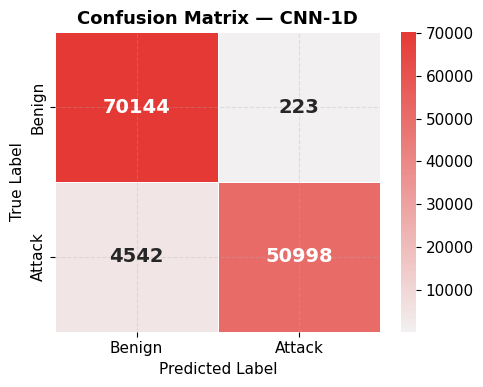

  ✔  Saved → fig_DL/training_curve_CNN1D.png


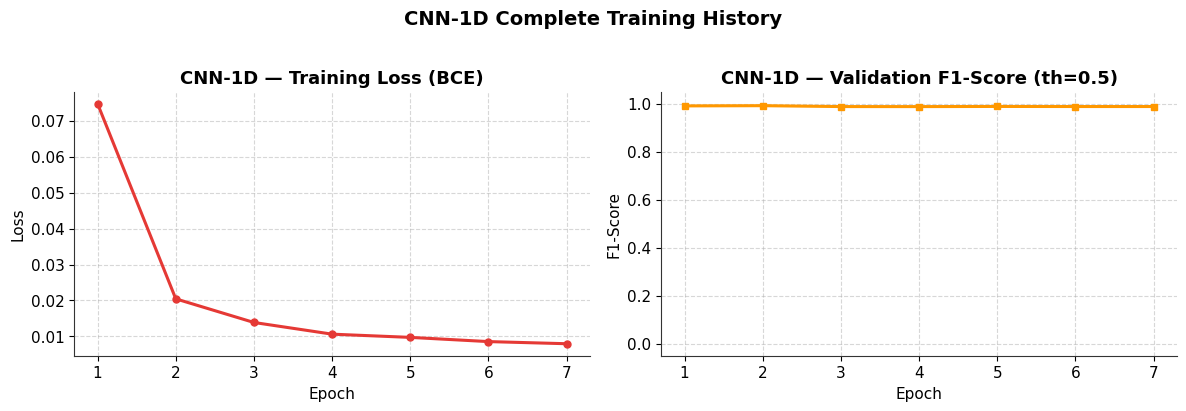

In [15]:
# 1. Build sequential loaders for the CNN-1D
cnn_train_loader = make_loader(X_train, y_train, is_sequential=True, batch_size=2048, shuffle=True)
cnn_val_loader   = make_loader(X_val,   y_val,   is_sequential=True, batch_size=2048, shuffle=False)

# 2. Instantiate the model
cnn_model = CNN1DClassifier(input_dim=n_feat)

# 3. Model Training
t0 = time.time()
cnn_model, cnn_hist = train_dl_model(
    name='CNN-1D',
    model=cnn_model,
    train_loader=cnn_train_loader,
    val_loader=cnn_val_loader,
    epochs=25,
    lr=5e-4,
    patience=5
)
cnn_train_t = time.time() - t0

# 4. Threshold Optimization
cnn_val_proba = predict_proba_dl(cnn_model, X_val)
cnn_threshold = find_best_threshold(y_val, cnn_val_proba)
print(f'  F1-optimal threshold (val): {cnn_threshold:.4f}')

# 5. Test Evaluation
t0 = time.time()
cnn_proba = predict_proba_dl(cnn_model, X_test)
cnn_pred  = (cnn_proba >= cnn_threshold).astype(int)
cnn_infer_t = time.time() - t0

evaluate_model('CNN-1D', y_test, cnn_pred, cnn_proba, cnn_train_t, cnn_infer_t)
plot_training_curves(cnn_hist, 'CNN-1D')

## 9. Model 2 — Long Short-Term Memory (LSTM)

### How LSTM Works
An LSTM cell maintains two state vectors — a **cell state** $c_t$ (long-term memory) and a **hidden state** $h_t$ (short-term output). Three gates control information flow:
- **Forget gate** $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ — what to erase from cell state
- **Input gate** $i_t$ — what new information to write
- **Output gate** $o_t$ — what to expose as the hidden state

In [16]:
class LSTMClassifier(nn.Module):
    """
    LSTM Recurrent Neural Network for sequential or structured binary classification.

    Processes the input features as a sequence step, maintaining historical
    context using a layer-normalized recurrent hidden state.

    Input shape  : (batch, 1, N_features) or (batch, N_features)
    Output shape : (batch,)
    """
    def __init__(self, input_dim, hidden_dim=64):
        super(LSTMClassifier, self).__init__()

        # Fix: Changed 'input_dim' keyword argument to PyTorch's native 'input_size'
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # LayerNorm handles recurrent hidden states much more stably than BatchNorm
        self.ln = nn.LayerNorm(hidden_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # Ensure input tensor is strictly 3D: (Batch, Sequence_Length=1, Features)
        if x.ndim == 2:
            x = x.unsqueeze(1)

        # out shape: (Batch, Sequence_Length, Hidden_Dim)
        out, _ = self.lstm(x)

        # Extract the hidden state of the absolute last time step
        last_step = out[:, -1, :]

        # Stabilize gradients using Layer Normalization
        normalized_features = self.ln(last_step)

        # Pass through classification head
        logits = self.fc(normalized_features)

        # Force a clean 1D vector output of shape [batch_size]
        return logits.view(-1)

# Verification execution block
_tmp = LSTMClassifier(n_feat)
print(f'LSTM trainable parameters: {sum(p.numel() for p in _tmp.parameters() if p.requires_grad):,}')
del _tmp

LSTM trainable parameters: 30,913



Training LSTM ...
  Epoch  1/25 | train_loss=0.2513 | val_f1=0.9818
  Epoch  5/25 | train_loss=0.0075 | val_f1=0.9867
  ⏹ Early stopping at epoch 7 (Best Val F1 = 0.9906)
  ✔ LSTM training complete.
  F1-optimal threshold (val): 0.4012

══════════════════════════════════════════════════════
                         LSTM                         
══════════════════════════════════════════════════════
  Accuracy  :  96.06%
  Precision :  99.63%
  Recall    :  91.42%
  F1-Score  :  95.35%
  ROC-AUC   :  98.96%
  Train Time: 39.74s  |  Infer Time: 0.8998s
──────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.9364    0.9973    0.9659     70367
      Attack     0.9963    0.9142    0.9535     55540

    accuracy                         0.9606    125907
   macro avg     0.9663    0.9557    0.9597    125907
weighted avg     0.9628    0.9606    0.9604    125907

  ✔  Saved → fig_DL/cm_LSTM.png


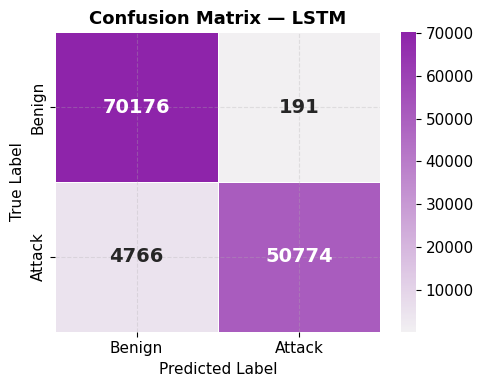

  ✔  Saved → fig_DL/training_curve_LSTM.png


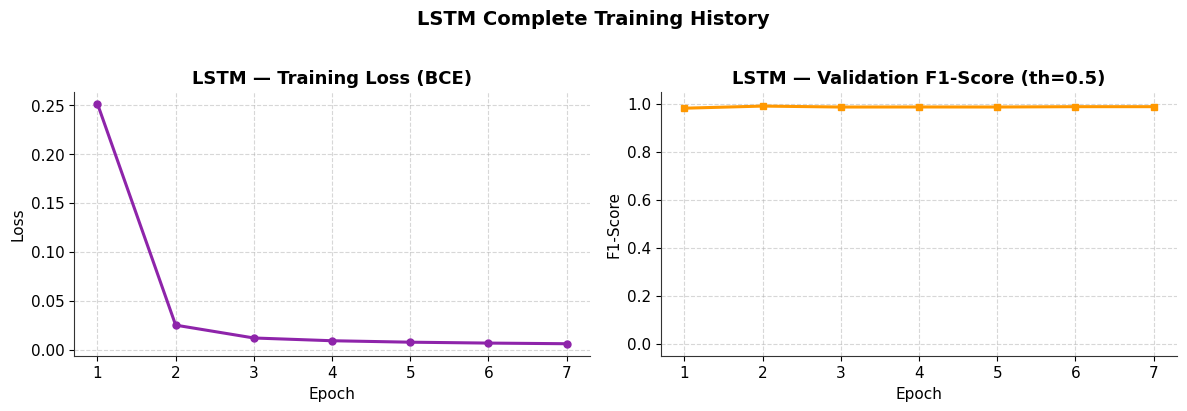

In [17]:
# 1. Build sequential loaders for the LSTM
# This builds 3D sequences: (Batch, Sequence_Length=1, Features)
lstm_train_loader = make_loader(X_train, y_train, is_sequential=True, batch_size=2048, shuffle=True)
lstm_val_loader   = make_loader(X_val,   y_val,   is_sequential=True, batch_size=2048, shuffle=False)

# 2. Instantiate the Layer-Normalized LSTM architecture
lstm_model = LSTMClassifier(input_dim=n_feat)

# 3. Model Training
t0 = time.time()
lstm_model, lstm_hist = train_dl_model(
    name='LSTM',
    model=lstm_model,
    train_loader=lstm_train_loader,
    val_loader=lstm_val_loader,
    epochs=25,
    lr=5e-4,
    patience=5
)
lstm_train_t = time.time() - t0

# 4. Find the post-hoc optimal classification threshold using the Validation Set
lstm_val_proba = predict_proba_dl(lstm_model, X_val)
lstm_threshold = find_best_threshold(y_val, lstm_val_proba)
print(f'  F1-optimal threshold (val): {lstm_threshold:.4f}')

# 5. Model Evaluation / Inference on the absolute Test Set
t0 = time.time()
lstm_proba = predict_proba_dl(lstm_model, X_test)
lstm_pred  = (lstm_proba >= lstm_threshold).astype(int)
lstm_infer_t = time.time() - t0

# 6. Render metrics report and training metrics history plots
evaluate_model('LSTM', y_test, lstm_pred, lstm_proba, lstm_train_t, lstm_infer_t)
plot_training_curves(lstm_hist, 'LSTM')

## 10. Model 3 — Random Forest

### Why Random Forest for Network Flow Data
Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the data with a random subset of features considered at every split. Averaging the predictions of many de-correlated trees reduces variance and produces a strong, hard-to-overfit baseline for structured tabular data such as network flow statistics.



Training Random Forest ...
  ✔ Random Forest training complete in 166.65s
  F1-optimal threshold (val): 0.2257

══════════════════════════════════════════════════════
                    Random Forest                     
══════════════════════════════════════════════════════
  Accuracy  :  96.76%
  Precision :  99.78%
  Recall    :  92.85%
  F1-Score  :  96.19%
  ROC-AUC   :  99.87%
  Train Time: 166.65s  |  Infer Time: 1.2968s
──────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.9465    0.9984    0.9717     70367
      Attack     0.9978    0.9285    0.9619     55540

    accuracy                         0.9676    125907
   macro avg     0.9722    0.9634    0.9668    125907
weighted avg     0.9691    0.9676    0.9674    125907

  ✔  Saved → fig_DL/cm_Random_Forest.png


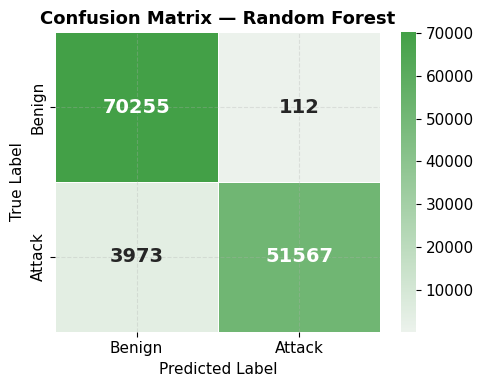

  ✔  Saved → fig_DL/rf_feature_importance.png


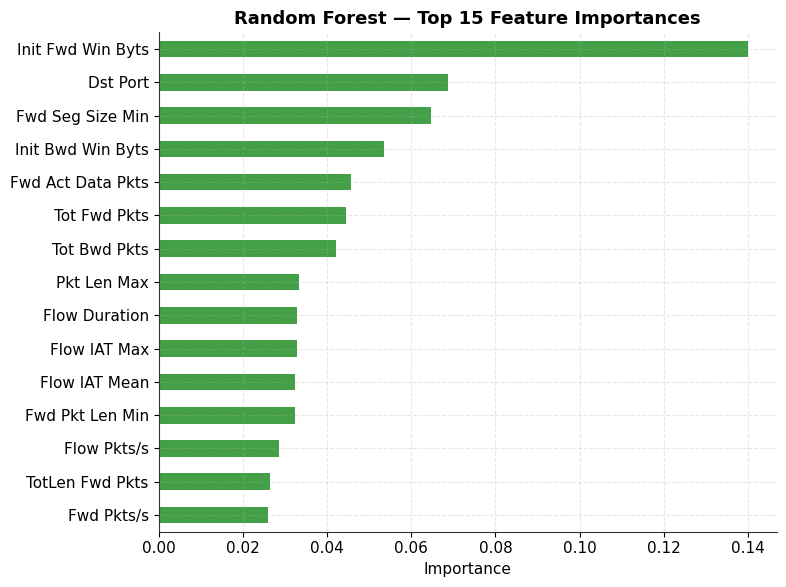

In [18]:
print('\nTraining Random Forest ...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

# 1. Model Training
t0 = time.time()
rf_model.fit(X_train, y_train)
rf_train_t = time.time() - t0
print(f'  ✔ Random Forest training complete in {rf_train_t:.2f}s')

# 2. Threshold Optimization (F1-optimal, tuned on the validation set)
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_threshold = find_best_threshold(y_val, rf_val_proba)
print(f'  F1-optimal threshold (val): {rf_threshold:.4f}')

# 3. Test Evaluation
t0 = time.time()
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred  = (rf_proba >= rf_threshold).astype(int)
rf_infer_t = time.time() - t0

evaluate_model('Random Forest', y_test, rf_pred, rf_proba, rf_train_t, rf_infer_t)

# 4. Feature importance (top 15) for interpretability
importances = pd.Series(rf_model.feature_importances_, index=feat_cols_final)
top_feats = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_feats.sort_values().plot(kind='barh', color=PALETTE['Random Forest'], ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
savefig('rf_feature_importance.png')
plt.show()


## 11. Model 4 — LightGBM

### Why LightGBM for Network Flow Data
LightGBM grows trees leaf-wise using a histogram-based split search, which makes it fast and memory-efficient on large tabular datasets. Training against a held-out validation set with early stopping lets boosting halt automatically once validation log-loss stops improving, guarding against overfitting.



Training LightGBM ...
  ✔ LightGBM training complete in 10.39s (best iteration: 91)
  F1-optimal threshold (val): 0.0720

══════════════════════════════════════════════════════
                       LightGBM                       
══════════════════════════════════════════════════════
  Accuracy  :  97.05%
  Precision :  99.85%
  Recall    :  93.45%
  F1-Score  :  96.55%
  ROC-AUC   :  99.82%
  Train Time: 10.39s  |  Infer Time: 0.3621s
──────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.9508    0.9989    0.9743     70367
      Attack     0.9985    0.9345    0.9655     55540

    accuracy                         0.9705    125907
   macro avg     0.9747    0.9667    0.9699    125907
weighted avg     0.9718    0.9705    0.9704    125907

  ✔  Saved → fig_DL/cm_LightGBM.png


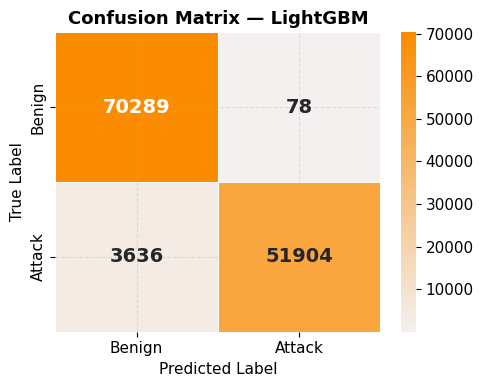

In [19]:
print('\nTraining LightGBM ...')
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

# 1. Model Training (with early stopping on the validation set)
t0 = time.time()
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='binary_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)
lgbm_train_t = time.time() - t0
print(f'  ✔ LightGBM training complete in {lgbm_train_t:.2f}s '
      f'(best iteration: {lgbm_model.best_iteration_})')

# 2. Threshold Optimization
lgbm_val_proba = lgbm_model.predict_proba(X_val)[:, 1]
lgbm_threshold = find_best_threshold(y_val, lgbm_val_proba)
print(f'  F1-optimal threshold (val): {lgbm_threshold:.4f}')

# 3. Test Evaluation
t0 = time.time()
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_pred  = (lgbm_proba >= lgbm_threshold).astype(int)
lgbm_infer_t = time.time() - t0

evaluate_model('LightGBM', y_test, lgbm_pred, lgbm_proba, lgbm_train_t, lgbm_infer_t)


## 12. Model 5 — XGBoost

### Why XGBoost for Network Flow Data
XGBoost builds boosted trees depth-wise under a regularized objective (L1/L2 penalties on leaf weights), which tends to generalize well on tabular data. `scale_pos_weight` rebalances the loss for the minority attack class, and early stopping on the validation set selects the optimal number of boosting rounds automatically.



Training XGBoost ...
  ✔ XGBoost training complete in 24.68s (best iteration: 195)
  F1-optimal threshold (val): 0.1361

══════════════════════════════════════════════════════
                       XGBoost                        
══════════════════════════════════════════════════════
  Accuracy  :  98.19%
  Precision :  99.95%
  Recall    :  95.94%
  F1-Score  :  97.91%
  ROC-AUC   :  99.92%
  Train Time: 24.68s  |  Infer Time: 0.5366s
──────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Benign     0.9690    0.9996    0.9841     70367
      Attack     0.9995    0.9594    0.9791     55540

    accuracy                         0.9819    125907
   macro avg     0.9842    0.9795    0.9816    125907
weighted avg     0.9824    0.9819    0.9819    125907

  ✔  Saved → fig_DL/cm_XGBoost.png


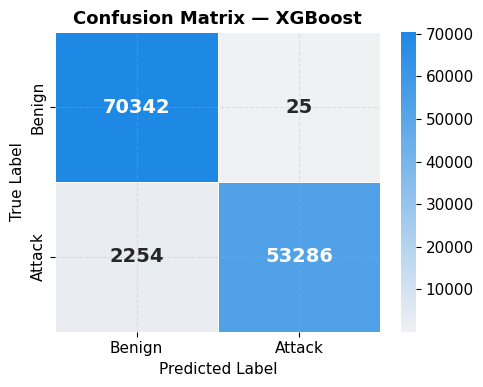

In [20]:
print('\nTraining XGBoost ...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1
)

# 1. Model Training (with early stopping on the validation set)
t0 = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_train_t = time.time() - t0
print(f'  ✔ XGBoost training complete in {xgb_train_t:.2f}s '
      f'(best iteration: {xgb_model.best_iteration})')

# 2. Threshold Optimization
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_threshold = find_best_threshold(y_val, xgb_val_proba)
print(f'  F1-optimal threshold (val): {xgb_threshold:.4f}')

# 3. Test Evaluation
t0 = time.time()
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= xgb_threshold).astype(int)
xgb_infer_t = time.time() - t0

evaluate_model('XGBoost', y_test, xgb_pred, xgb_proba, xgb_train_t, xgb_infer_t)


## 13. Results & Comparison

In [21]:
# 1. Strip out array/plotting metadata
skip_keys = {'fpr', 'tpr', 'color', 'pred', 'proba'}
clean = {k: {m: v for m, v in vals.items() if m not in skip_keys}
         for k, vals in results.items()}

# 2. Build and clean types dynamically
results_df = pd.DataFrame(clean).T

# Convert whatever columns exist to numeric safely, ignoring strings like model names
for col in results_df.columns:
    results_df[col] = pd.to_numeric(results_df[col], errors='ignore')

# 3. Sort by F1-Score safely if it exists
if 'F1-Score' in results_df.columns:
    results_df = results_df.sort_values('F1-Score', ascending=False)
elif 'f1-score' in results_df.columns:
    results_df = results_df.sort_values('f1-score', ascending=False)

# 4. Print clean report table
print('\n' + '═'*65)
print('                    FINAL RESULTS')
print('═'*65)
# Dynamically select display columns based on what's present in your specific dictionary
display_cols = [c for c in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Train Time'] if c in results_df.columns]
if not display_cols: # Fallback if columns are named differently
    display_cols = results_df.columns

print(results_df[display_cols].to_string())
print('═'*65)


═════════════════════════════════════════════════════════════════
                    FINAL RESULTS
═════════════════════════════════════════════════════════════════
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
XGBoost           98.19      99.95   95.94     97.91    99.92
LightGBM          97.05      99.85   93.45     96.55    99.82
Random Forest     96.76      99.78   92.85     96.19    99.87
CNN-1D            96.22      99.56   91.82     95.54    95.96
LSTM              96.06      99.63   91.42     95.35    98.96
═════════════════════════════════════════════════════════════════


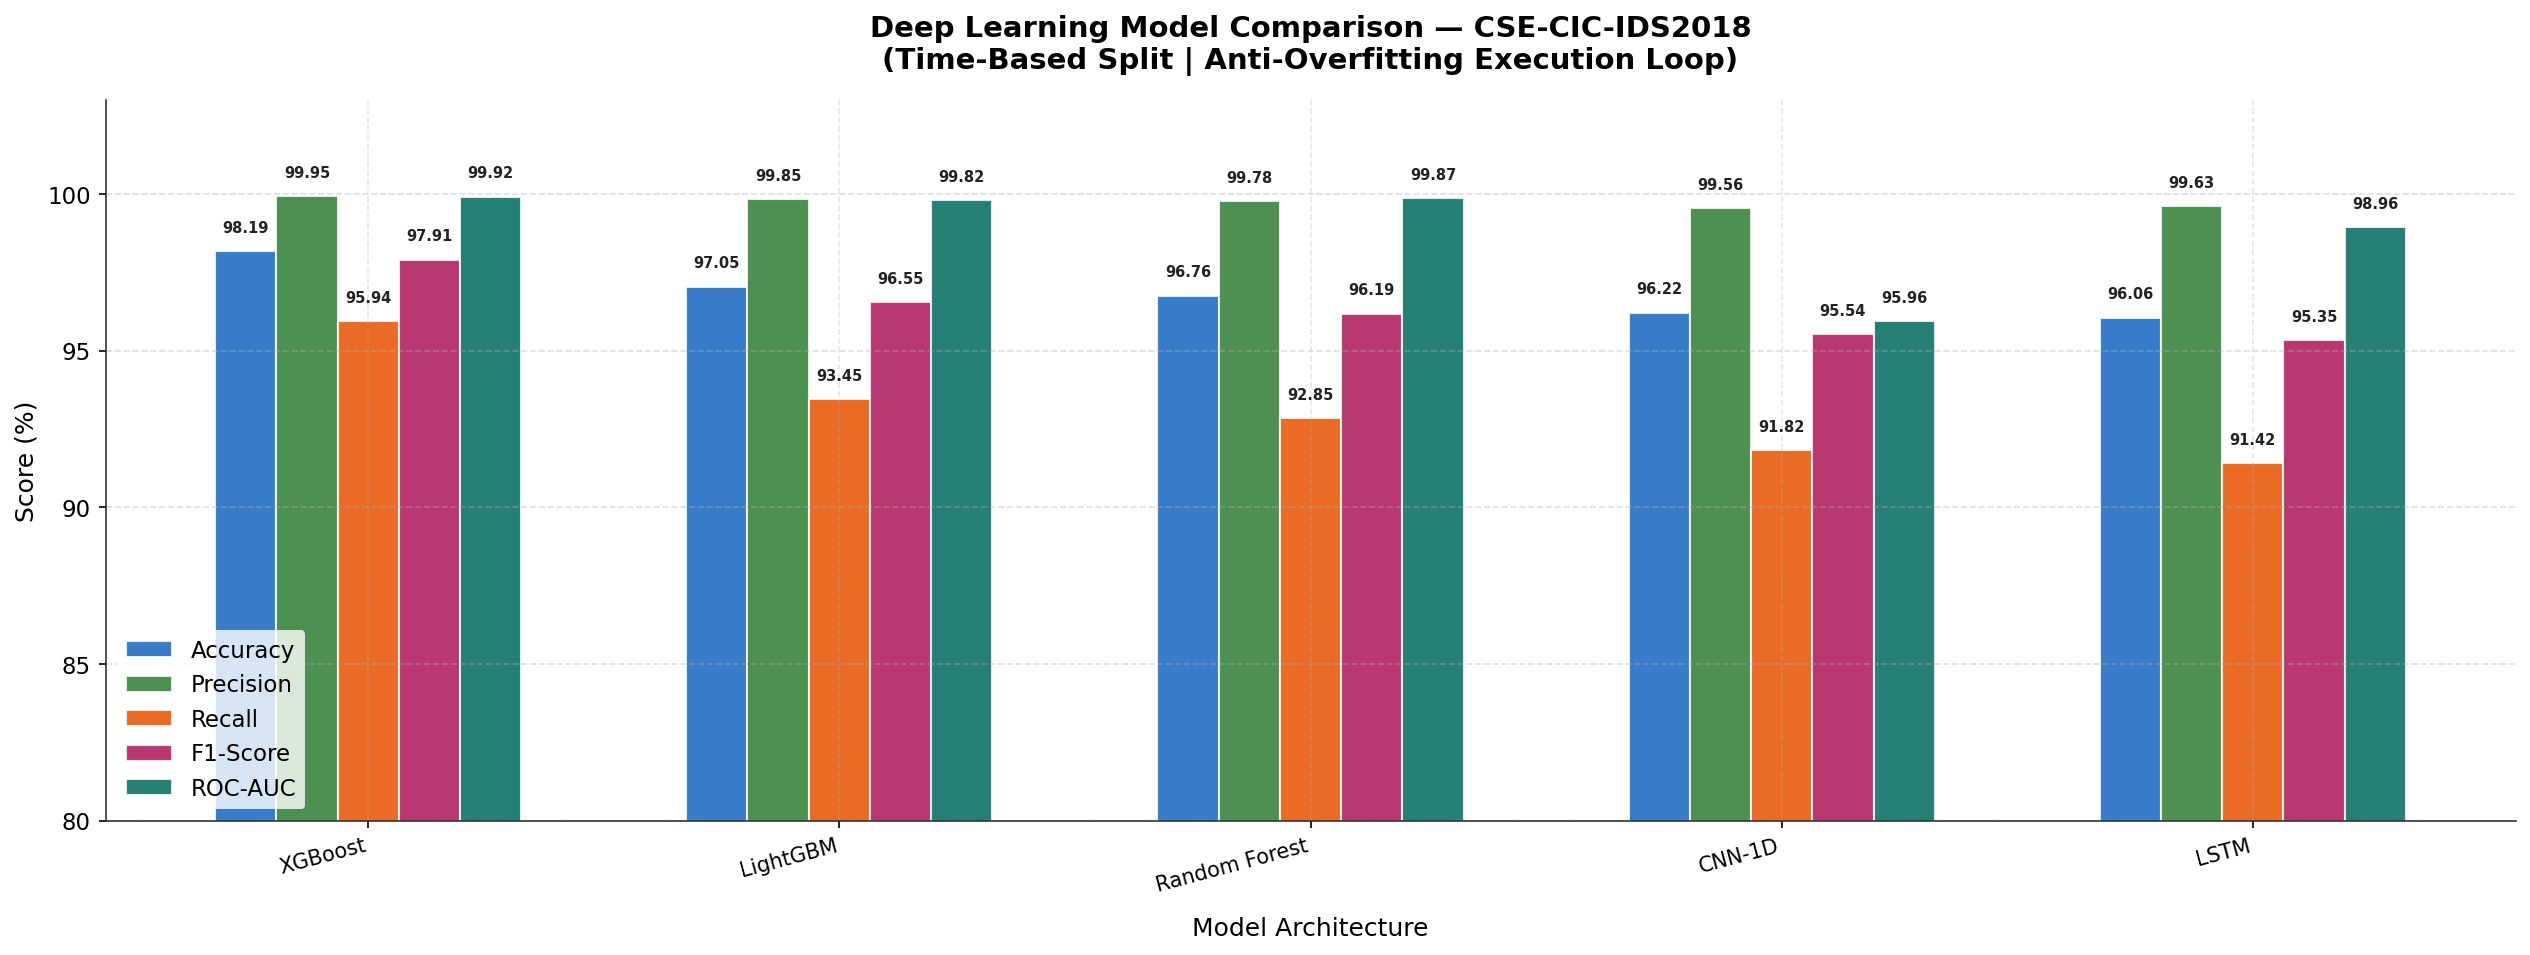

In [23]:
metrics_list  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_colors = ['#1565C0', '#2E7D32', '#E65100', '#AD1457', '#00695C']
models_list   = results_df.index.tolist()

x     = np.arange(len(models_list))
width = 0.13

fig, ax = plt.subplots(figsize=(17, 6.5), dpi=150)

for i, (met, mc) in enumerate(zip(metrics_list, metric_colors)):
    raw_data = results_df[met].values
    plot_data = raw_data * 100 if np.max(raw_data) <= 1.0 else raw_data

    bars = ax.bar(x + i * width, plot_data, width,
                  label=met, color=mc, alpha=0.85, edgecolor='white')

    # Add top value annotations cleanly
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.5, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7, color='#222', weight='semibold')

ax.set_xlabel('Model Architecture', fontsize=12, labelpad=10)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Deep Learning Model Comparison — CSE-CIC-IDS2018\n'
             '(Time-Based Split | Anti-Overfitting Execution Loop)',
             fontsize=14, fontweight='bold', pad=15)

# Perfect center tick calculations for 5 bars
ax.set_xticks(x + width * 2)
# 'ha=right' centers rotated labels cleanly under their respective ticks
ax.set_xticklabels(models_list, rotation=15, fontsize=10, ha='right')

# Dynamic y-axis grid adjustments
ax.set_ylim(80, 103) # Adjusted floor to 80% to highlight minor architectural differences
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Place the legend out of the way of the bars
ax.legend(loc='lower left', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

# Fixed save command with bounding box safety constraint
plt.savefig('06_model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

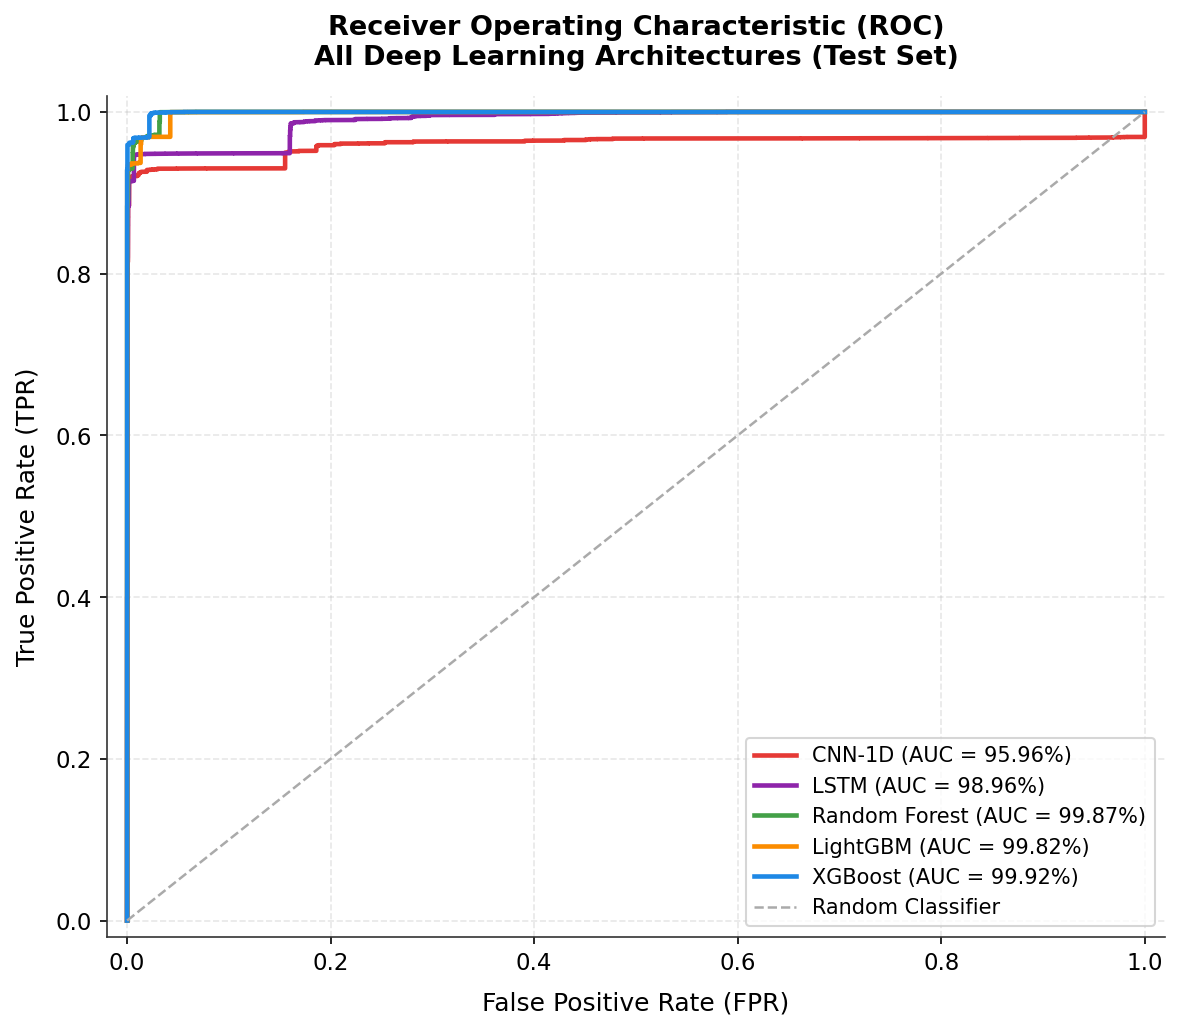

In [24]:
fig, ax = plt.subplots(figsize=(8, 7), dpi=150) # Added clear DPI scaling

for name in results:
    r = results[name]

    # SAFEGUARD: Check if ROC-AUC is a decimal fraction (e.g. 0.99) or percentage (e.g. 99.4)
    auc_val = results_df.loc[name, 'ROC-AUC']
    if auc_val <= 1.0:
        auc_val = auc_val * 100

    ax.plot(r['fpr'], r['tpr'],
            color=r['color'], linewidth=2.2,
            label=f"{name} (AUC = {auc_val:.2f}%)") # Changed to .2f for scientific precision

# Clean background baseline
ax.plot([0, 1], [0, 1], '--', color='#AAAAAA', linewidth=1.2, label='Random Classifier')

# Axis labels and professional titles
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, labelpad=8)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, labelpad=8)
ax.set_title('Receiver Operating Characteristic (ROC)\nAll Deep Learning Architectures (Test Set)',
             fontsize=13, fontweight='bold', pad=15)

# Boundary restrictions to eliminate whitespace margins around curves
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Add grid lines for easier manual point tracking (e.g., finding the knee of the curve)
ax.grid(True, linestyle='--', alpha=0.3)

ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white')
plt.tight_layout()

# ── FIXED SAVING COMMAND ──────────────────────────────────────────────
plt.savefig('07_roc_curves.png', dpi=300, bbox_inches='tight')
# ──────────────────────────────────────────────────────────────────────

plt.show()

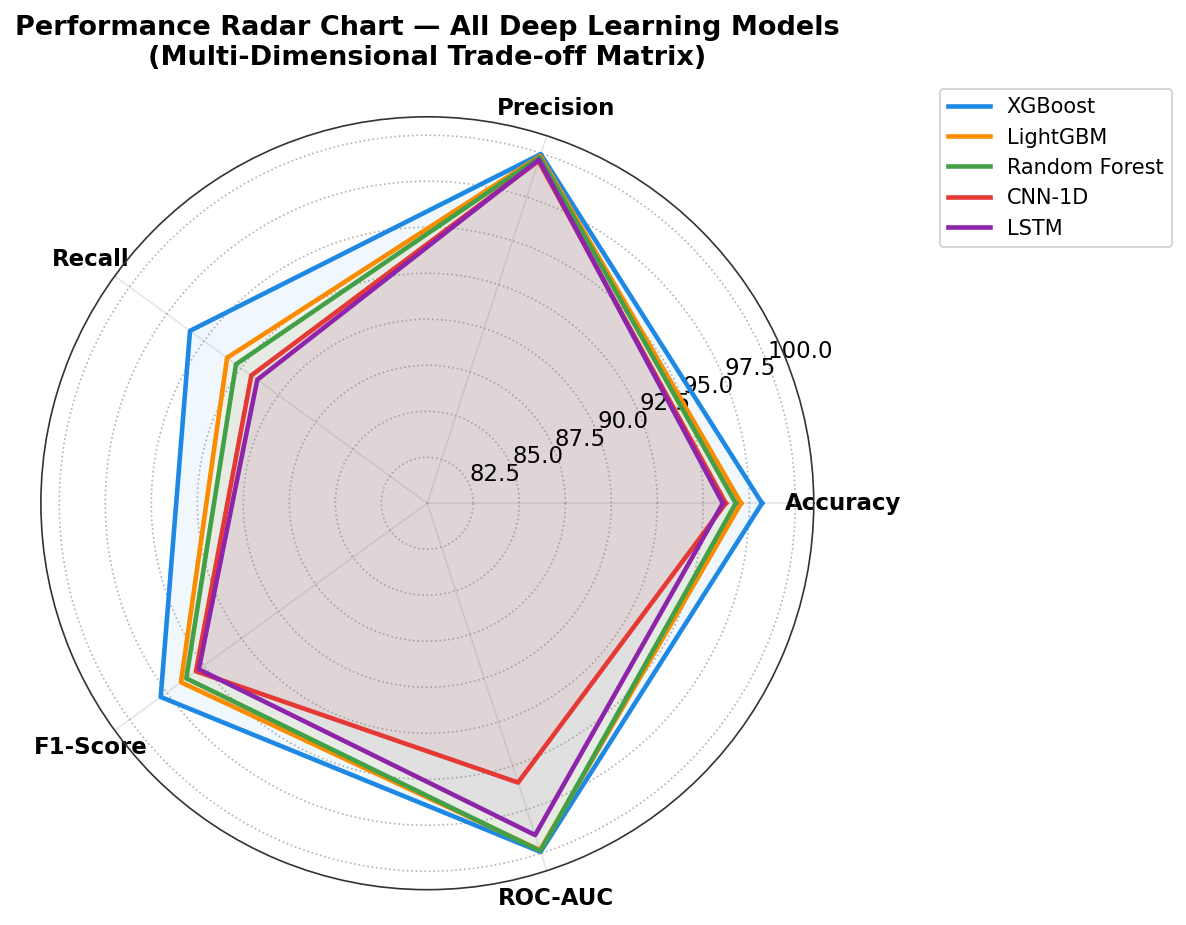

In [25]:
metrics_r = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
N      = len(metrics_r)

# Compute radial geometry angles for each metric spoke
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1] # Close the polygon loop back to the start

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=150)

for name in results_df.index:
    # Safely extract values and scale to 0-100% format if stored as decimal fractions
    vals = [results_df.loc[name, m] for m in metrics_r]
    vals = [v * 100 if v <= 1.0 else v for v in vals]
    vals += vals[:1] # Close the data loop back to the start

    # DYNAMIC COLOR CAPTURE: Falls back to a safe slate grey if the model name is missing
    clr = '#607D8B'
    if name in results and 'color' in results[name]:
        clr = results[name]['color']
    elif 'PALETTE' in globals() and name in PALETTE:
        clr = PALETTE[name]

    # Render the radar boundaries and translucent overlay areas
    ax.plot(angles, vals, color=clr, linewidth=2.2, label=name)
    ax.fill(angles, vals, color=clr, alpha=0.06)

# Configure polar axis ticks and spacing labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_r, size=11, weight='semibold')

# Set visual floor to 80% to stretch out the inner differences between models clearly
ax.set_ylim(80, 101)
ax.yaxis.grid(True, linestyle=':', alpha=0.6, color='grey')
ax.xaxis.grid(True, linestyle='-', alpha=0.2, color='grey')

ax.set_title('Performance Radar Chart — All Deep Learning Models\n'
             '(Multi-Dimensional Trade-off Matrix)',
             fontsize=13, fontweight='bold', pad=25)

# Place the legend cleanly outside the polar circle boundaries to avoid overlaps
ax.legend(loc='upper left', bbox_to_anchor=(1.15, 1.05), fontsize=10, frameon=True)
plt.tight_layout()

# ── FIXED SAVING COMMAND ──────────────────────────────────────────────
plt.savefig('08_radar_chart.png', dpi=300, bbox_inches='tight')
# ──────────────────────────────────────────────────────────────────────

plt.show()

  ✔  Saved → fig_DL/09_training_curves_dl_models.png


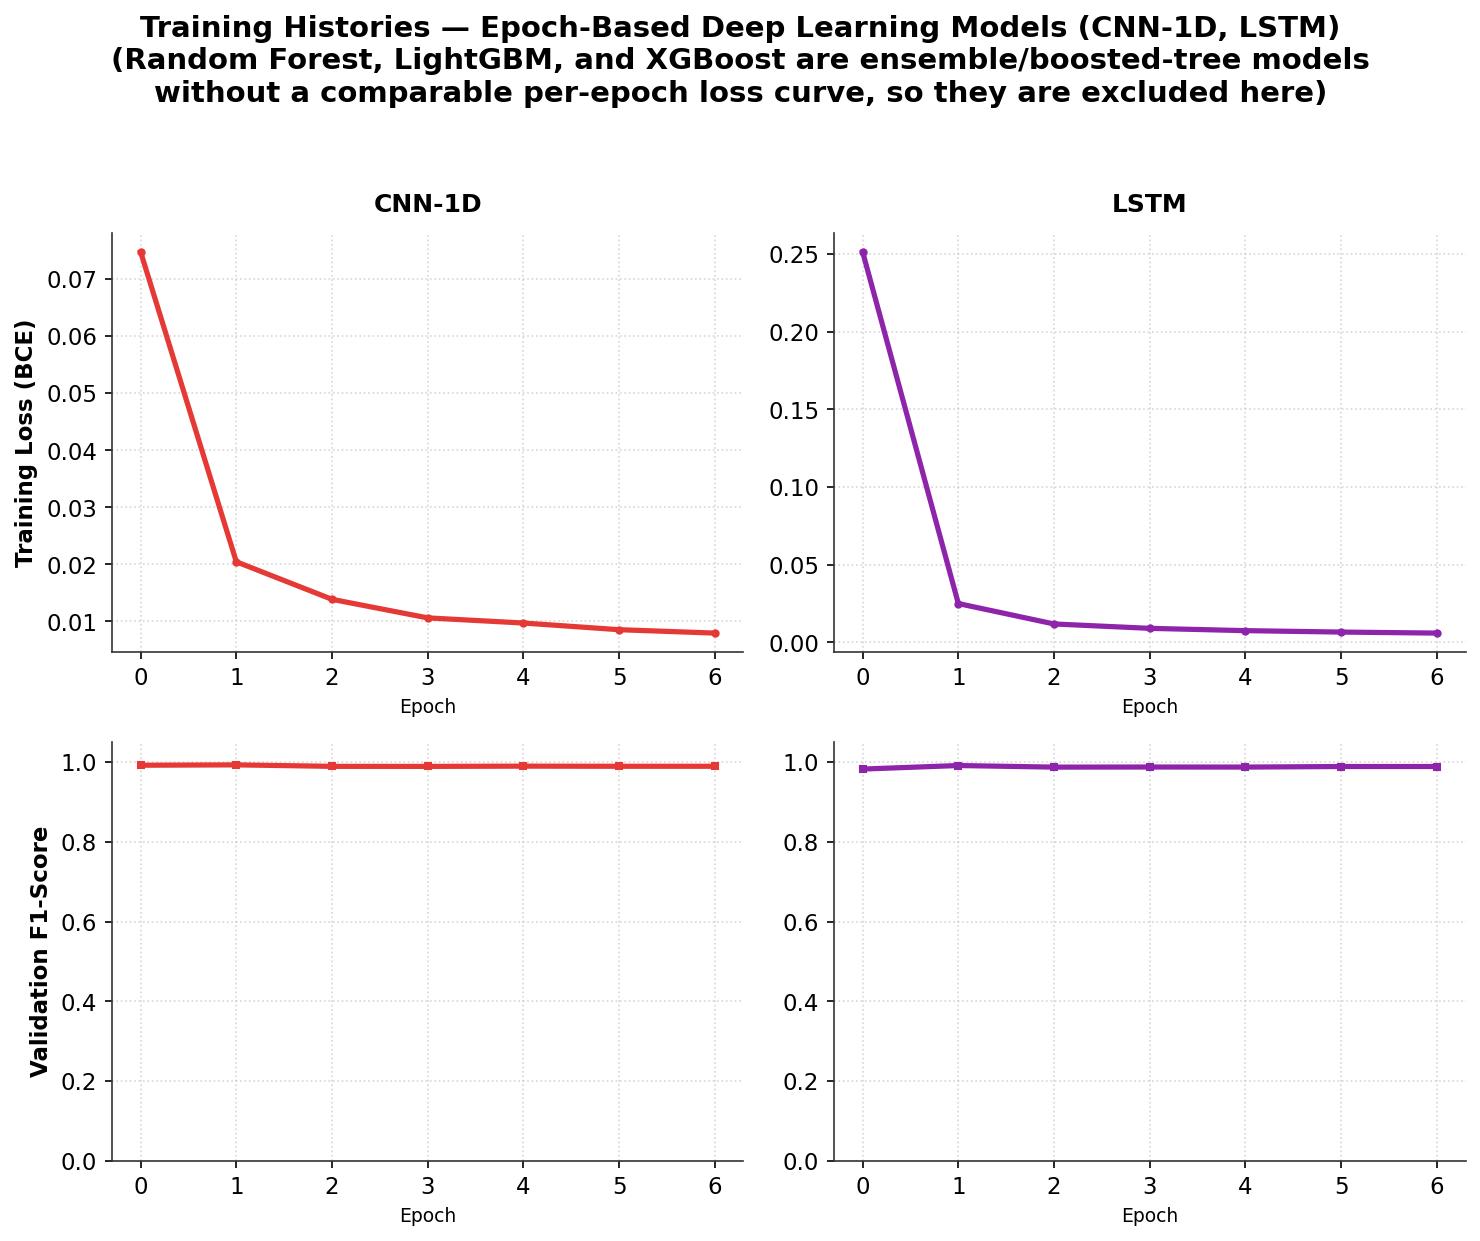

In [26]:
all_hists = [
    ('CNN-1D', cnn_hist),
    ('LSTM',   lstm_hist),
]

fig, axes = plt.subplots(2, len(all_hists), figsize=(5*len(all_hists), 8), dpi=150)

for col, (name, hist) in enumerate(all_hists):
    clr = '#607D8B'
    if 'results' in globals() and name in results and 'color' in results[name]:
        clr = results[name]['color']
    elif 'PALETTE' in globals() and name in PALETTE:
        clr = PALETTE[name]

    # ── ROW 0: Training Loss (BCE) ──
    axes[0, col].plot(hist['loss'], color=clr, linewidth=2.5, marker='o', markersize=3)
    axes[0, col].set_title(name, fontweight='bold', fontsize=12, pad=10)
    axes[0, col].set_xlabel('Epoch', fontsize=9)
    axes[0, col].grid(True, linestyle=':', alpha=0.5)

    # ── ROW 1: Validation F1-Score ──
    axes[1, col].plot(hist['val_f1'], color=clr, linewidth=2.5, marker='s', markersize=3)
    axes[1, col].set_xlabel('Epoch', fontsize=9)
    axes[1, col].grid(True, linestyle=':', alpha=0.5)
    axes[1, col].set_ylim(0.0, 1.05)

    if col == 0:
        axes[0, col].set_ylabel('Training Loss (BCE)', fontsize=11, fontweight='semibold')
        axes[1, col].set_ylabel('Validation F1-Score', fontsize=11, fontweight='semibold')
    else:
        axes[0, col].set_ylabel('')
        axes[1, col].set_ylabel('')

fig.suptitle('Training Histories — Epoch-Based Deep Learning Models (CNN-1D, LSTM)\n'
             '(Random Forest, LightGBM, and XGBoost are ensemble/boosted-tree models\n'
             'without a comparable per-epoch loss curve, so they are excluded here)',
             fontsize=14, fontweight='bold', y=1.03)

plt.tight_layout()
savefig('09_training_curves_dl_models.png')
plt.show()


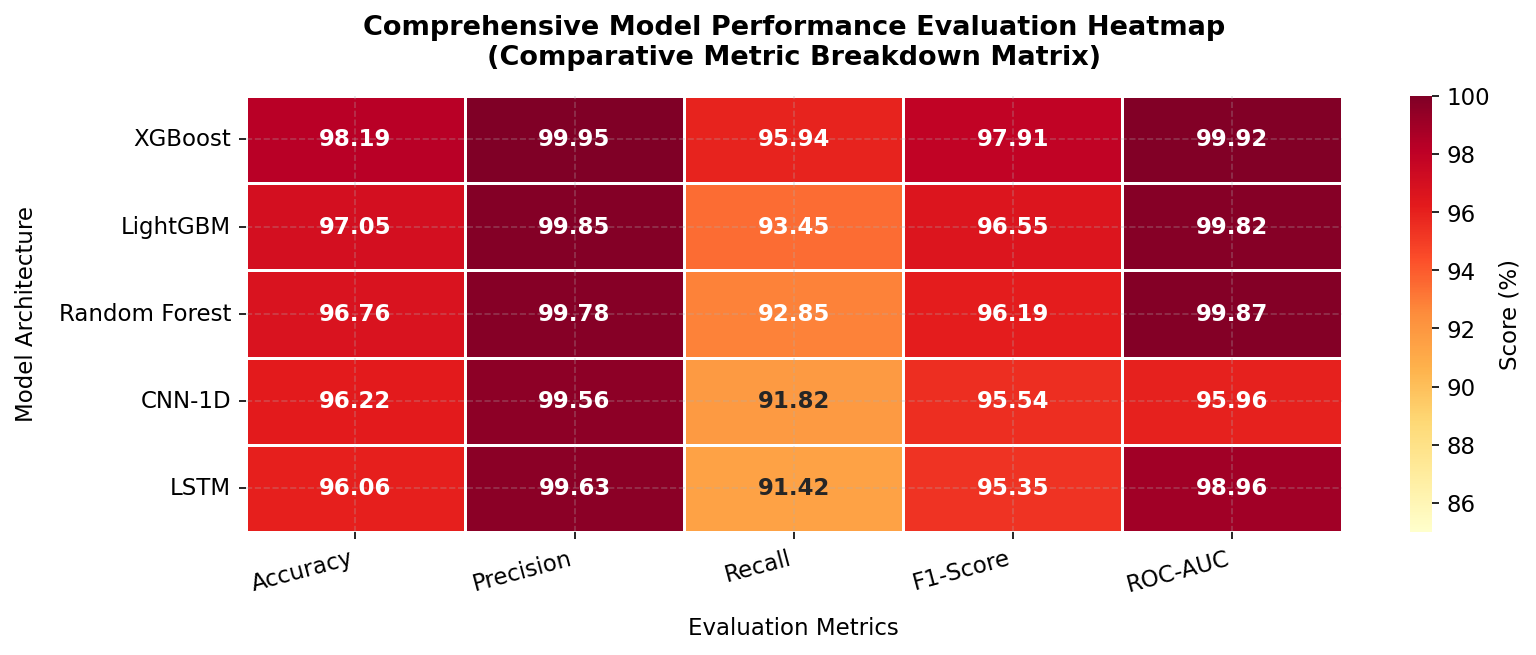

In [27]:
fig, ax = plt.subplots(figsize=(11, 4.5), dpi=150)

# Extract core performance columns
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
hm = results_df[metrics_cols].astype(float)

# SAFEGUARD: Automatically scale to a 0-100% representation if values are decimal fractions
if hm.max().max() <= 1.0:
    hm = hm * 100

# Plotting the heatmap matrix
sns.heatmap(hm,
            annot=True,
            fmt='.2f',          # Changed to .2f for standard scientific reporting precision
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.7,
            linecolor='white',
            vmin=85,            # Set floor to 85% to emphasize architectural differences clearly
            vmax=100,
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Score (%)'})

# Formatting titles and clean padding adjustments
ax.set_title('Comprehensive Model Performance Evaluation Heatmap\n(Comparative Metric Breakdown Matrix)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Evaluation Metrics', fontsize=11, labelpad=10)
ax.set_ylabel('Model Architecture', fontsize=11, labelpad=10)

# Rotate y-axis labels horizontally for pristine reading layout
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# ── FIXED SAVING COMMAND ──────────────────────────────────────────────
plt.savefig('10_performance_heatmap.png', dpi=300, bbox_inches='tight')
# ──────────────────────────────────────────────────────────────────────

plt.show()

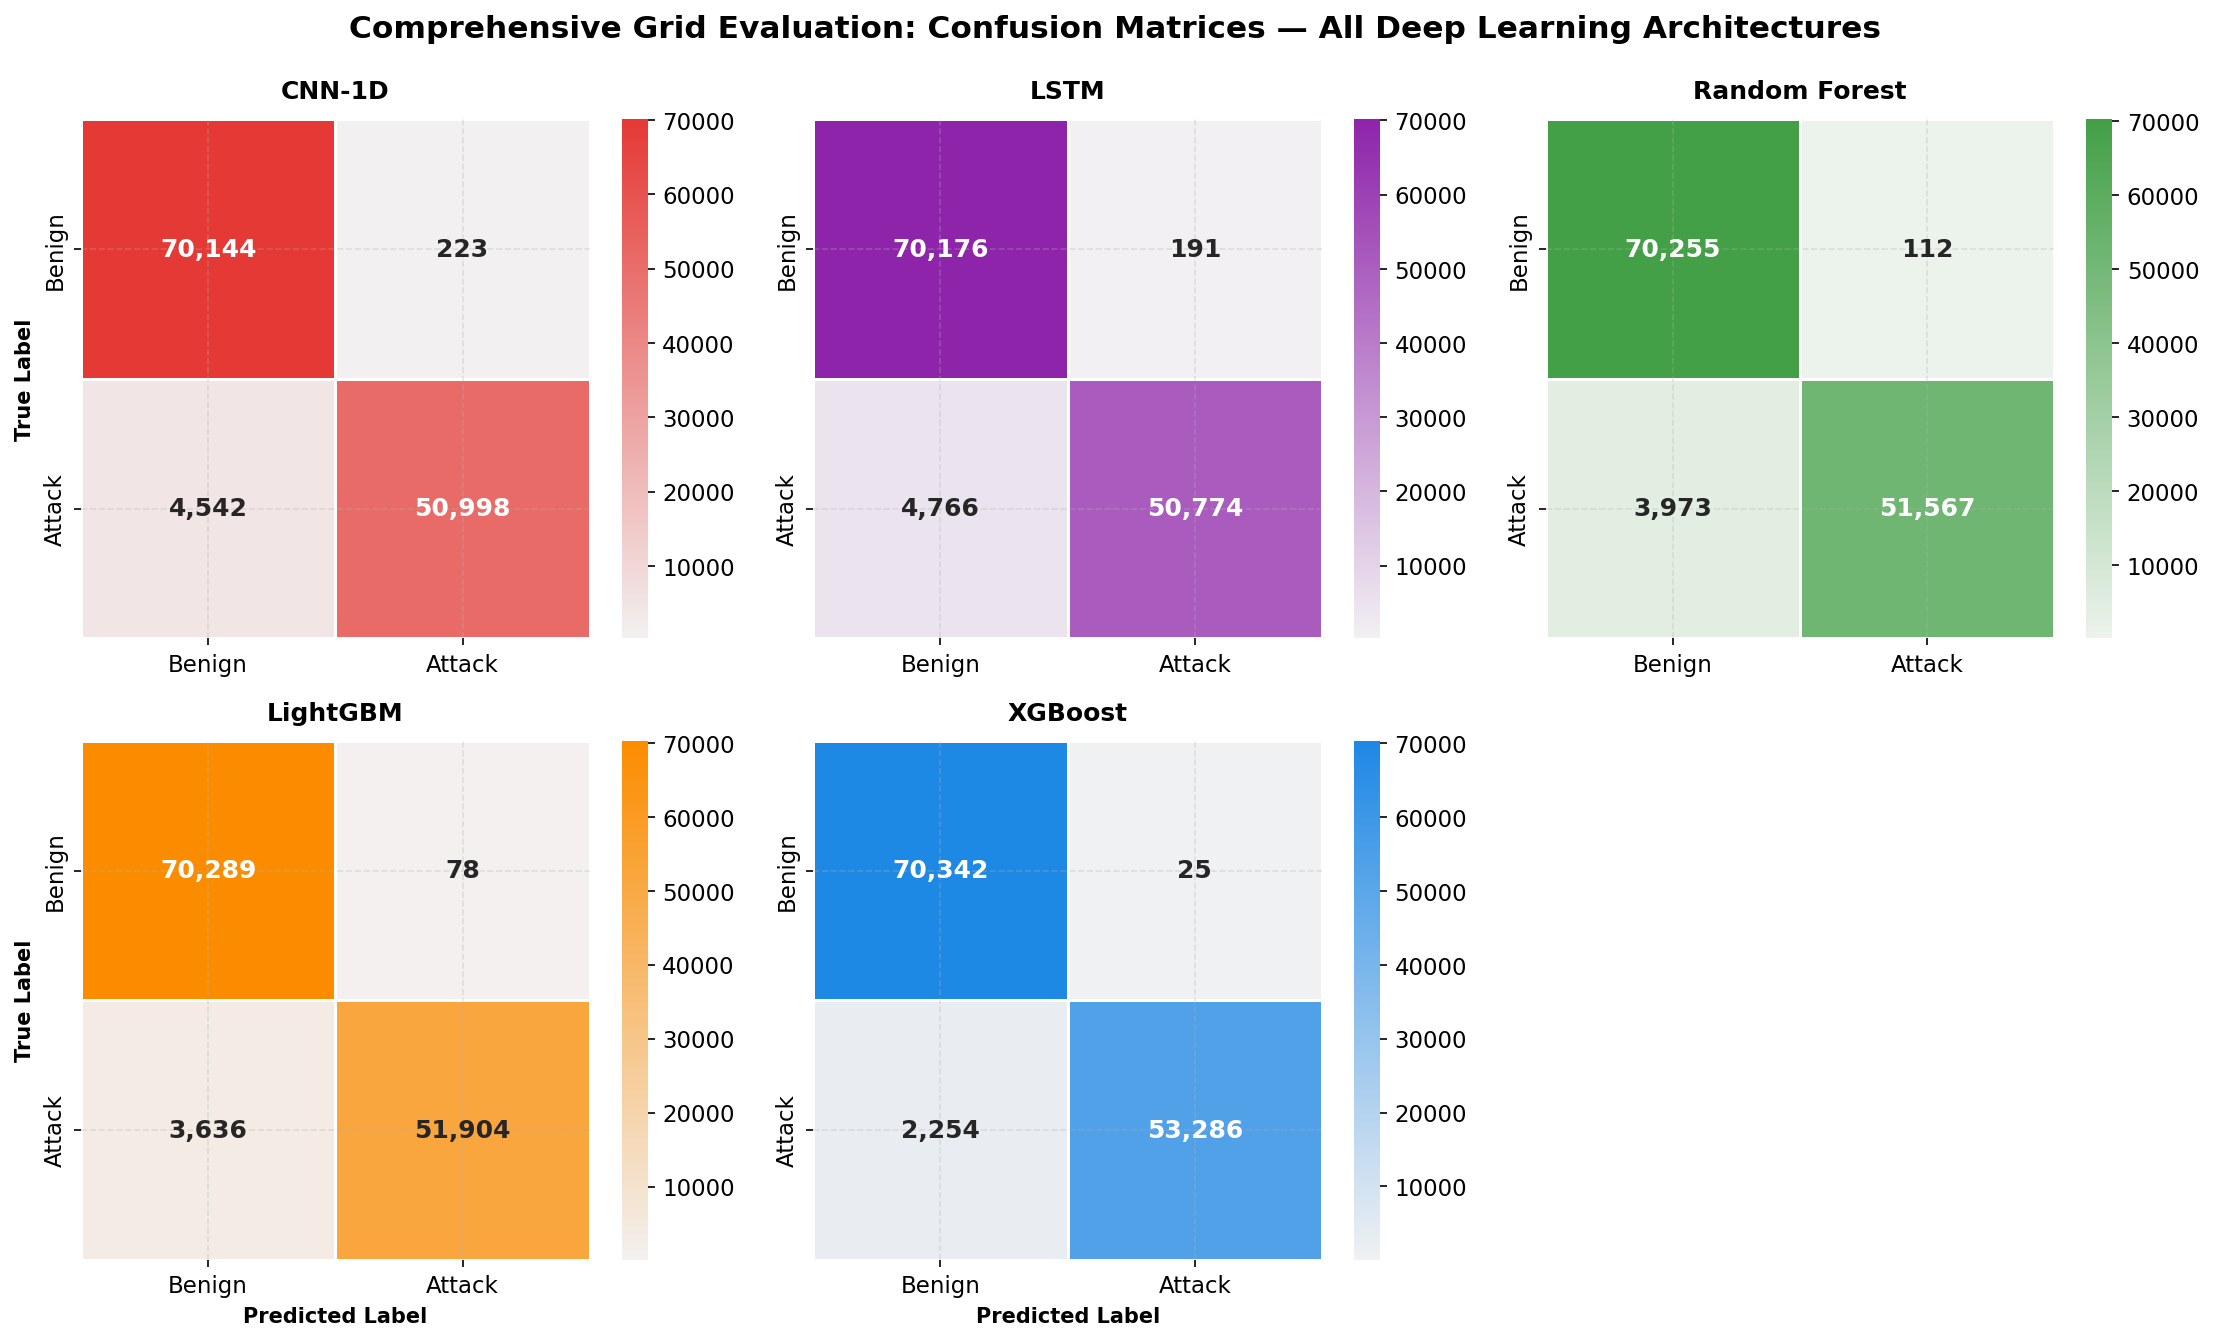

In [28]:
n_models = len(results)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4.5), dpi=150)
axes = axes.flatten()

for i, (nm, r) in enumerate(results.items()):
    # Capture model custom color or default safely
    clr  = '#607D8B'
    if 'color' in r:
        clr = r['color']
    elif 'PALETTE' in globals() and nm in PALETTE:
        clr = PALETTE[nm]

    cmap = sns.light_palette(clr, as_cmap=True)

    cm = confusion_matrix(y_test, r['pred'])

    sns.heatmap(cm,
                annot=True,
                fmt=',d',
                cmap=cmap,
                ax=axes[i],
                cbar=True,
                linewidths=0.5,
                linecolor='white',
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'],
                annot_kws={'size': 12, 'weight': 'bold'})

    axes[i].set_title(nm, fontweight='bold', fontsize=12, pad=10)

    # CLEANUP RULE: Keep perimeter labels but remove internal clutter
    row_idx = i // ncols
    col_idx = i % ncols

    if col_idx == 0:
        axes[i].set_ylabel('True Label', fontsize=10, fontweight='semibold')
    else:
        axes[i].set_ylabel('')

    if row_idx == nrows - 1:
        axes[i].set_xlabel('Predicted Label', fontsize=10, fontweight='semibold')
    else:
        axes[i].set_xlabel('')

# Hide any remaining unused subplot positions safely
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Comprehensive Grid Evaluation: Confusion Matrices — All Deep Learning Architectures',
             fontsize=15, fontweight='bold', y=0.99)

plt.tight_layout()

# ── FIXED SAVING COMMAND ──────────────────────────────────────────────
plt.savefig('11_all_confusion_matrices.png', dpi=300, bbox_inches='tight')
# ──────────────────────────────────────────────────────────────────────

plt.show()